# Witcher Character Network Analysis

> A graph-based character relationship analysis project using NetworkX to study character importance, relationship density, centrality, and community structure within the Witcher universe.

## Data Loading
> Loading the dataset

In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/content/drive/MyDrive/DATASETS/witcher_small_network.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  250 non-null    int64 
 1   Source      250 non-null    object
 2   Target      250 non-null    object
 3   Type        250 non-null    object
 4   Weight      250 non-null    int64 
 5   book        250 non-null    int64 
dtypes: int64(3), object(3)
memory usage: 11.8+ KB


In [4]:
df = df.drop(columns=["Unnamed: 0"])

In [5]:
df["Source"] = df["Source"].str.strip()
df["Target"] = df["Target"].str.strip()

df.head()

,Source,Target,Type,Weight,book
0,Geralt,Adda,Undirected,3,1
1,Geralt,Foltest,Undirected,5,1
2,Foltest,Geralt,Undirected,5,1
3,Adda,Geralt,Undirected,1,1
4,Foltest,Adda,Undirected,1,1


## Data Exploration


In [6]:
# STANDARDIZING CHARACTER PAIRS FOR AN UNDIRECTED GRAPH
# Example: Geralt - Ciri and Ciri - Geralt should be treated as the same relationship

df["Character_1"] = df.apply(
    lambda row: sorted([row["Source"], row["Target"]])[0],
    axis=1
)

df["Character_2"] = df.apply(
    lambda row: sorted([row["Source"], row["Target"]])[1],
    axis=1
)

# CHECKING HOW ORIGINAL SOURCE-TARGET PAIRS WERE CONVERTED
df[["Source", "Target", "Character_1", "Character_2", "Weight", "book"]].head(10)

,Source,Target,Character_1,Character_2,Weight,book
0,Geralt,Adda,Adda,Geralt,3,1
1,Geralt,Foltest,Foltest,Geralt,5,1
2,Foltest,Geralt,Foltest,Geralt,5,1
3,Adda,Geralt,Adda,Geralt,1,1
4,Foltest,Adda,Adda,Foltest,1,1
5,Geralt,Yennefer,Geralt,Yennefer,24,1
6,Yennefer,Geralt,Geralt,Yennefer,24,1
7,Geralt,Merigold,Geralt,Merigold,1,1
8,Geralt,Eskel,Eskel,Geralt,1,1
9,Geralt,Vesemir,Geralt,Vesemir,1,1


In [7]:
# COUNTING HOW MANY TIMES EACH CHARACTER PAIR APPEARS

repeated_pairs = (
    df.groupby(["Character_1", "Character_2"])   # GROUPING SAME CHARACTER PAIRS TOGETHER
    .size()                                      # COUNTING HOW MANY ROWS EACH PAIR HAS
    .reset_index(name="Times_Repeated")          # MAKING THE COUNT A NEW COLUMN
    .sort_values(by="Times_Repeated", ascending=False)  # SHOWING MOST REPEATED PAIRS FIRST
)

repeated_pairs.head(10)

,Character_1,Character_2,Times_Repeated
45,Geralt,Yennefer,14
13,Ciri,Geralt,12
23,Dandelion,Geralt,12
10,Ciri,Dandelion,12
21,Ciri,Yennefer,10
16,Ciri,Philippa,10
29,Dandelion,Yennefer,10
54,Philippa,Yennefer,10
39,Geralt,Merigold,9
50,Merigold,Yennefer,9


In [8]:
print("Number of unique character pairs:", len(repeated_pairs))

Number of unique character pairs: 58


The original dataset contains 250 rows, where the same character pair may appear multiple times across books or in reverse order. Since this project treats relationships as undirected, repeated pairs were combined into single unique relationships by summing their weights.

In [9]:
# EXAMPLE

example = repeated_pairs.iloc[0]

char1 = example["Character_1"]
char2 = example["Character_2"]

df[
    (df["Character_1"] == char1) &
    (df["Character_2"] == char2)
][["Source", "Target", "Weight", "book"]]

,Source,Target,Weight,book
5,Geralt,Yennefer,24,1
6,Yennefer,Geralt,24,1
11,Yennefer,Geralt,39,2
12,Geralt,Yennefer,15,2
34,Geralt,Yennefer,24,3
38,Yennefer,Geralt,20,3
100,Geralt,Yennefer,30,4
108,Yennefer,Geralt,24,4
162,Yennefer,Geralt,11,5
168,Geralt,Yennefer,5,5


In [10]:
# COMBINING ALL THE REPEATED RELATIONSHIPS
clean_edges = df.groupby(["Character_1", "Character_2"], as_index=False).agg(

    # ADDING ALL WEIGHTS FOR THE SAME CHARACTER PAIR
    Total_Weight=("Weight", "sum"),

    # COUNTING HOW MANY TIMES THE SAME PAIR APPEARED
    Times_Repeated=("Weight", "count"),

    # STORING THE BOOK NUMBERS WHERE THE PAIR APPEARED
    Books=("book", lambda x: ", ".join(map(str, sorted(set(x)))))
)


# RENAMING CHARACTER_1 AND CHARACTER_2 BACK TO SOURCE AND TARGET
clean_edges = clean_edges.rename(columns={
    "Character_1": "Source",
    "Character_2": "Target"
})


# CHECKING BEFORE AND AFTER COUNTS
print("Original rows:", len(df))
print("Unique relationships after combining:", len(clean_edges))

clean_edges.head(6)

Original rows: 250
Unique relationships after combining: 58


,Source,Target,Total_Weight,Times_Repeated,Books
0,Adda,Ciri,4,3,"3, 4"
1,Adda,Foltest,1,1,1
2,Adda,Geralt,5,3,"1, 7"
3,Chivay,Ciri,2,2,7
4,Chivay,Dandelion,19,3,"5, 7"
5,Chivay,Geralt,25,4,"5, 7"


## Network Graph

In [11]:
# CREATING AN EMPTY UNDIRECTED GRAPH
G = nx.Graph()

# ADDING EACH CLEANED CHARACTER PAIR AS A RELATIONSHIP IN THE GRAPH
for _, row in clean_edges.iterrows():
    G.add_edge(
        row["Source"],
        row["Target"],
        weight=row["Total_Weight"],
        times_repeated=row["Times_Repeated"],
        books=row["Books"]
    )

# CHECKING BASIC NETWORK DETAILS
print("Number of characters:", G.number_of_nodes())
print("Number of relationships:", G.number_of_edges())
print("Network density:", nx.density(G))
print("Is connected:", nx.is_connected(G))

Number of characters: 15
Number of relationships: 58
Network density: 0.5523809523809524
Is connected: True


> Who has the most connections

Connections = how many characters they are linked to

> Who has the strongest relationships overall

Relationship_Strength = how strong all their links are combined

In [12]:
# COUNTING HOW MANY CHARATERS EACH CHARACTER IS CONNECTED TO
degree_dict = dict(G.degree())

# COUNTING TOTAL RELATIONSHIP STRENGTH
weighted_degree_dict = dict(G.degree(weight="weight"))

# CREATING A TABLE WITH CHARACTER NAME, CONNECTIONS AND STRENGTH
character_stats = pd.DataFrame({
    "Character": list(G.nodes()),
    "Connections": [degree_dict[node] for node in G.nodes()],
    "Relationship_Strength": [weighted_degree_dict[node] for node in G.nodes()]
})


# SORTING CHARACTERS BY 'MOST CONNECTIONS' THEN 'RELATIONSHIP STRENGTH'
character_stats = character_stats.sort_values(
    by=["Connections", "Relationship_Strength"],
    ascending=False
)

character_stats.head(15)

,Character,Connections,Relationship_Strength
3,Geralt,14,1421
1,Ciri,14,1096
9,Yennefer,10,816
5,Dandelion,10,796
7,Philippa,10,219
2,Foltest,8,53
6,Merigold,7,111
13,Vesemir,7,91
8,Scoia,7,65
4,Chivay,7,52


> Betweenness = bridge character

This shows which characters act as bridges between different parts of the network


> Eigenvector = influential character connected to important characters

This shows characters connected to other important characters

In [13]:
# CALCULATING BETWEENNESS CENTRALITY
betweenness_dict = nx.betweenness_centrality(G, weight="weight")


# CALCULATING EIGENVECTOR CENTRALITY
eigenvector_dict = nx.eigenvector_centrality(G, weight="weight", max_iter=1000)


# ADDING CENTRALITY SCORES TO CHARACTER STATS TABLE
character_stats["Betweenness_Centrality"] = character_stats["Character"].map(betweenness_dict)
character_stats["Eigenvector_Centrality"] = character_stats["Character"].map(eigenvector_dict)


# SORTING BY EIGENVECTOR CENTRALITY TO SEE MOST INFLUENTIAL CHARACTERS
character_stats = character_stats.sort_values(
    by="Eigenvector_Centrality",
    ascending=False
)

character_stats.head(15)

,Character,Connections,Relationship_Strength,Betweenness_Centrality,Eigenvector_Centrality
3,Geralt,14,1421,0.010989,0.607051
1,Ciri,14,1096,0.137363,0.501627
5,Dandelion,10,796,0.000000,0.436047
9,Yennefer,10,816,0.184982,0.418424
7,Philippa,10,219,0.212454,0.088846
6,Merigold,7,111,0.159341,0.042655
13,Vesemir,7,91,0.142857,0.038791
8,Scoia,7,65,0.000000,0.032255
4,Chivay,7,52,0.388278,0.027260
2,Foltest,8,53,0.269231,0.025195


## Network Visualization

> Bigger node = character has more connections

> Thicker line = stronger relationship

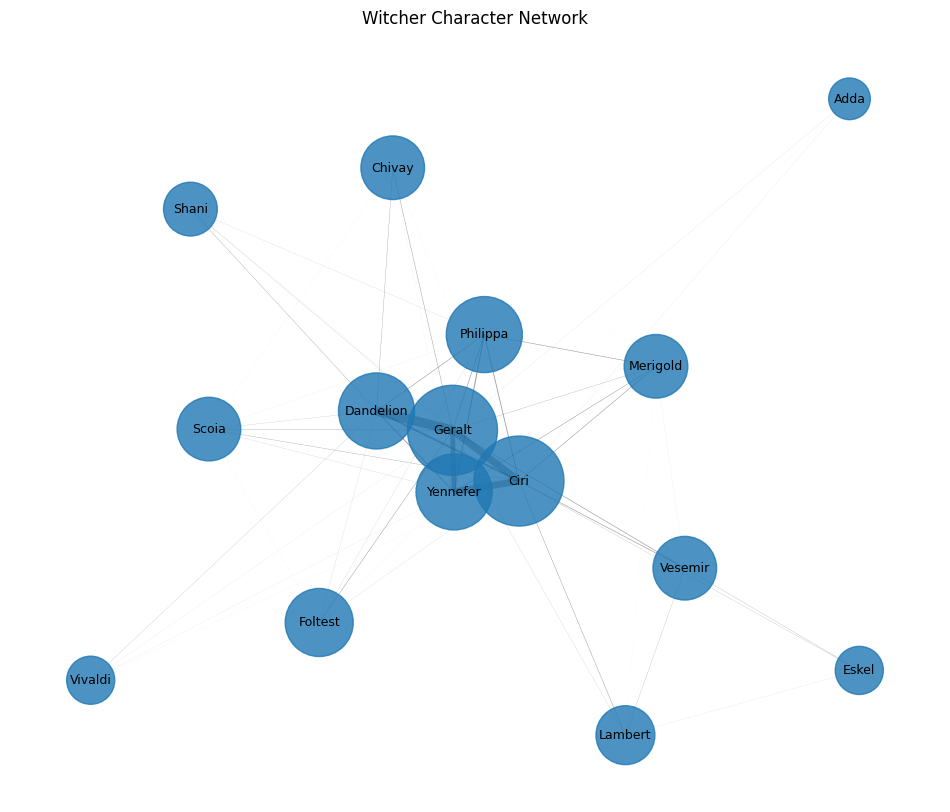

In [14]:
# VISUALIZING THE WITCHER CHARACTER NETWORK

plt.figure(figsize=(12, 10))

# CREATING POSITIONS FOR EACH CHARACTER NODE
pos = nx.spring_layout(G, seed=42)

# NODE SIZE BASED ON NUMBER OF CONNECTIONS
node_sizes = [degree_dict[node] * 300 for node in G.nodes()]

# EDGE WIDTH BASED ON RELATIONSHIP STRENGTH
edge_widths = [G[u][v]["weight"] / 80 for u, v in G.edges()]

# DRAWING CHARACTER NODES
nx.draw_networkx_nodes(
    G,
    pos,
    node_size=node_sizes,
    alpha=0.8
)

# DRAWING RELATIONSHIPS
nx.draw_networkx_edges(
    G,
    pos,
    width=edge_widths,
    alpha=0.4
)

# DRAWING CHARACTER NAMES
nx.draw_networkx_labels(
    G,
    pos,
    font_size=9
)

plt.title("Witcher Character Network")
plt.axis("off")
plt.show()

### Which characters are connected to the most other characters

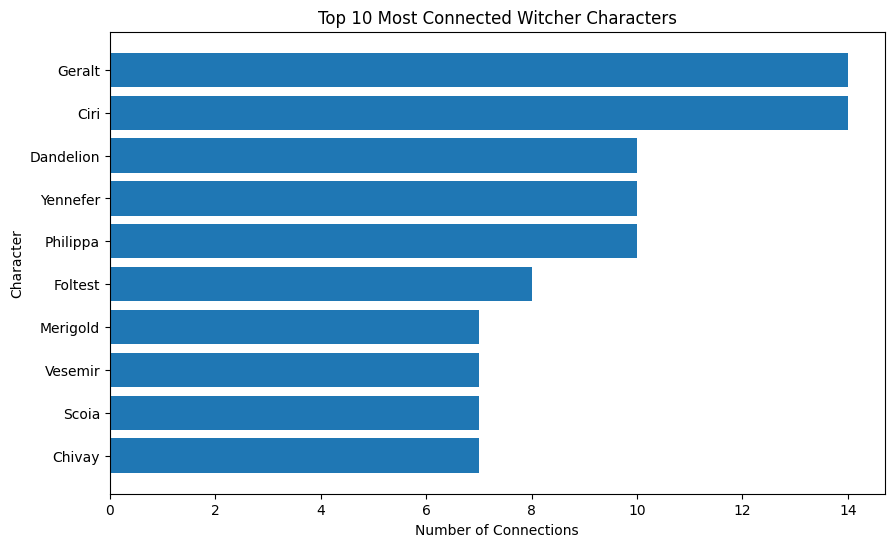

In [15]:
# SHOWING TOP 10 CHARACTERS BY NUMBER OF CONNECTIONS

top_10_characters = character_stats.sort_values(
    by="Connections",
    ascending=False
).head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_characters["Character"],
    top_10_characters["Connections"]
)

plt.xlabel("Number of Connections")
plt.ylabel("Character")
plt.title("Top 10 Most Connected Witcher Characters")

plt.gca().invert_yaxis()
plt.show()

### Which characters have the strongest overall relationships

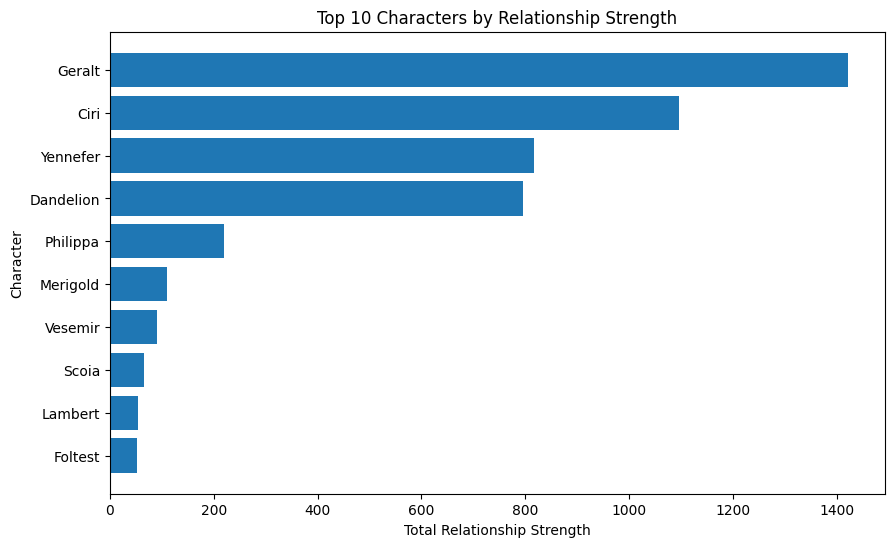

In [16]:
# SHOWING TOP 10 CHARACTERS BY TOTAL RELATIONSHIP STRENGTH

top_10_strength = character_stats.sort_values(
    by="Relationship_Strength",
    ascending=False
).head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_strength["Character"],
    top_10_strength["Relationship_Strength"]
)

plt.xlabel("Total Relationship Strength")
plt.ylabel("Character")
plt.title("Top 10 Characters by Relationship Strength")

plt.gca().invert_yaxis()
plt.show()

### Which character pairs have the strongest relationships based on total weight

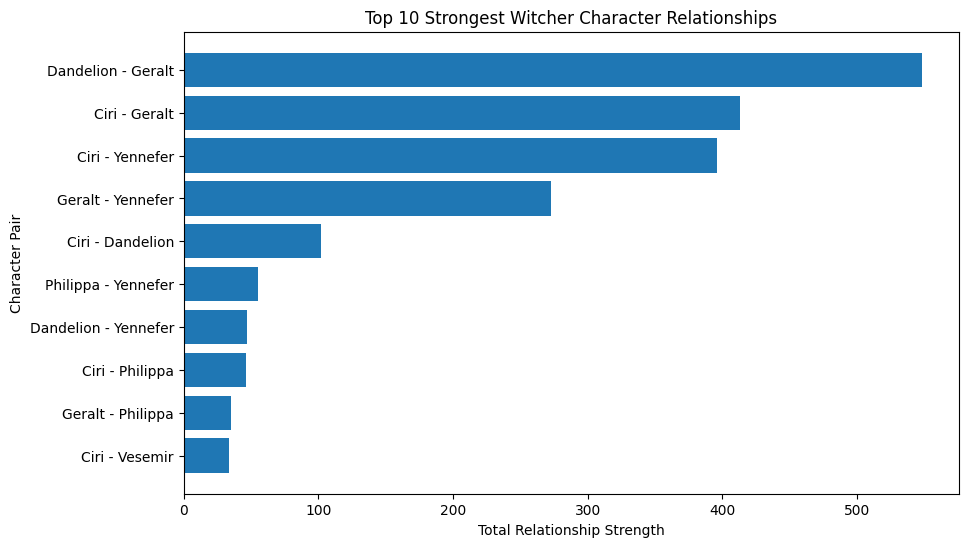

In [17]:
# SHOWING TOP 10 STRONGEST CHARACTER RELATIONSHIPS

top_10_relationships = clean_edges.sort_values(
    by="Total_Weight",
    ascending=False
).head(10).copy()

top_10_relationships["Relationship"] = (
    top_10_relationships["Source"] + " - " + top_10_relationships["Target"]
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_relationships["Relationship"],
    top_10_relationships["Total_Weight"]
)

plt.xlabel("Total Relationship Strength")
plt.ylabel("Character Pair")
plt.title("Top 10 Strongest Witcher Character Relationships")

plt.gca().invert_yaxis()
plt.show()

## Community Detection

In [18]:
# FINDING CHARACTER COMMUNITIES / GROUPS IN THE NETWORK

communities = nx.community.greedy_modularity_communities(G, weight="weight")

# CONVERTING COMMUNITY RESULTS INTO A READABLE TABLE
community_data = []

for i, community in enumerate(communities, start=1):
    for character in community:
        community_data.append({
            "Community": i,
            "Character": character
        })

community_df = pd.DataFrame(community_data)

community_df.sort_values(by="Community")

,Community,Character
0,1,Shani
1,1,Geralt
2,1,Chivay
3,1,Scoia
4,1,Vivaldi
5,1,Dandelion
6,1,Foltest
7,1,Adda
8,2,Philippa
9,2,Merigold


In [19]:
# CHECKING NUMBER OF CHARACTERS IN EACH COMMUNITY
community_df["Community"].value_counts().sort_index()

,count
Community,
1,8
2,4
3,3


In [20]:
# ADDING COMMUNITY NUMBER TO EACH NODE

community_map = {}

for i, community in enumerate(communities, start=1):
    for character in community:
        community_map[character] = i

> Same color = same community/group

> Bigger node = more connected character

>Thicker line = stronger relationship

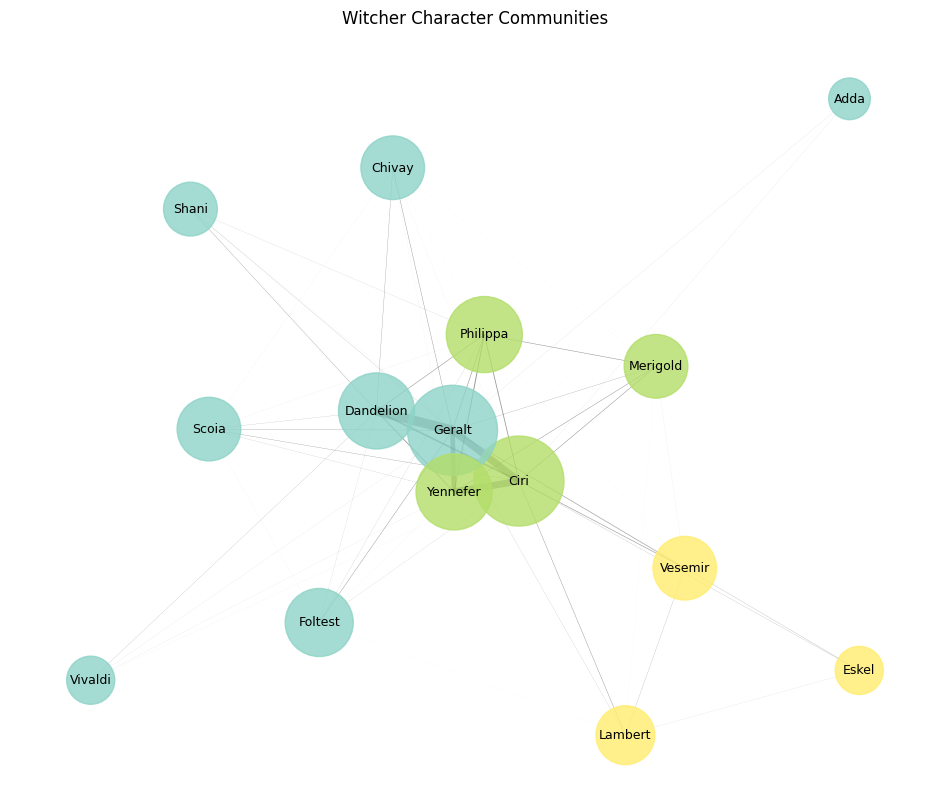

In [21]:
# VISUALIZING NETWORK WITH COMMUNITIES

plt.figure(figsize=(12, 10))

pos = nx.spring_layout(G, seed=42)

node_colors = [community_map[node] for node in G.nodes()]
node_sizes = [degree_dict[node] * 300 for node in G.nodes()]
edge_widths = [G[u][v]["weight"] / 80 for u, v in G.edges()]

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=node_sizes,
    node_color=node_colors,
    alpha=0.8,
    cmap=plt.cm.Set3
)

nx.draw_networkx_edges(
    G,
    pos,
    width=edge_widths,
    alpha=0.4
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=9
)

plt.title("Witcher Character Communities")
plt.axis("off")
plt.show()

## Book-wise Relationship Analysis

### Which books have more character relationship activity in the dataset

In [22]:
# COUNTING NUMBER OF RELATIONSHIP RECORDS IN EACH BOOK

book_relationships = df["book"].value_counts().sort_index()

book_relationships

,count
book,
1,11
2,18
3,66
4,43
5,42
6,21
7,49


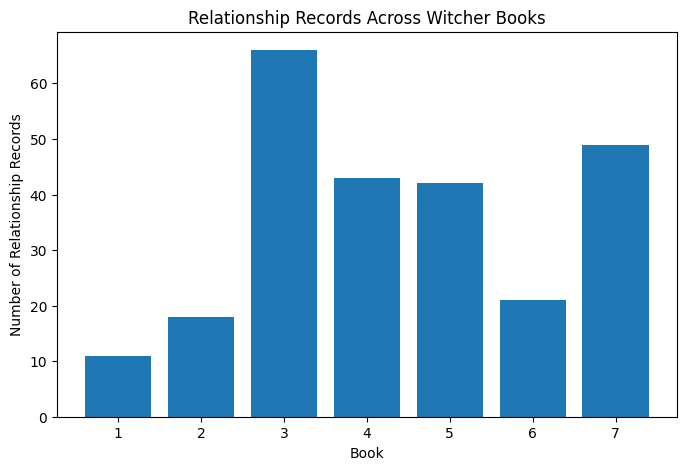

In [23]:
# VISUALIZING RELATIONSHIP RECORDS ACROSS BOOKS

plt.figure(figsize=(8, 5))

plt.bar(
    book_relationships.index,
    book_relationships.values
)

plt.xlabel("Book")
plt.ylabel("Number of Relationship Records")
plt.title("Relationship Records Across Witcher Books")

plt.show()

### Which books contain stronger character interactions based on total weight

In [24]:
# TOTAL RELATIONSHIP STRENGTH BY BOOK

book_strength = df.groupby("book")["Weight"].sum()

book_strength

,Weight
book,
1,67
2,394
3,722
4,253
5,448
6,122
7,433


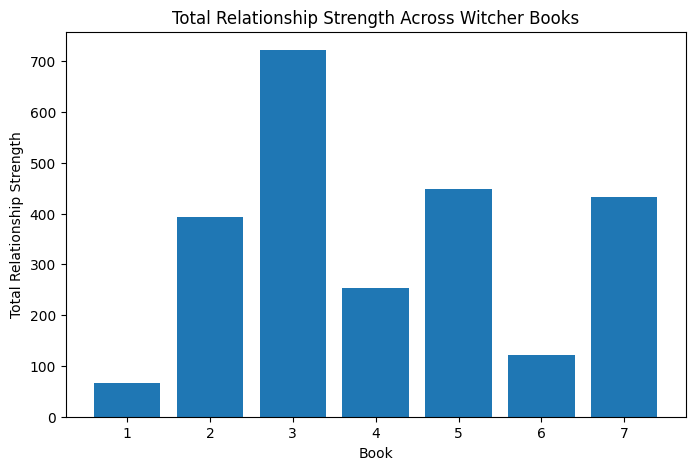

In [25]:
# VISUALIZING TOTAL RELATIONSHIP STRENGTH ACROSS BOOKS

plt.figure(figsize=(8, 5))

plt.bar(
    book_strength.index,
    book_strength.values
)

plt.xlabel("Book")
plt.ylabel("Total Relationship Strength")
plt.title("Total Relationship Strength Across Witcher Books")

plt.show()

## Book-wise Character Importance

In [26]:
# FINDING TOP CHARACTERS BY RELATIONSHIP STRENGTH IN EACH BOOK

book_character_strength = pd.concat([
    df[["book", "Source", "Weight"]].rename(columns={"Source": "Character"}),
    df[["book", "Target", "Weight"]].rename(columns={"Target": "Character"})
])

book_character_strength = (
    book_character_strength
    .groupby(["book", "Character"], as_index=False)["Weight"]
    .sum()
)

top_character_each_book = (
    book_character_strength
    .sort_values(["book", "Weight"], ascending=[True, False])
    .groupby("book")
    .head(1)
)

top_character_each_book

,book,Character,Weight
3,1,Geralt,65
9,2,Geralt,369
15,3,Ciri,429
36,4,Yennefer,157
41,5,Geralt,275
47,6,Ciri,76
57,7,Ciri,256


## Overall Character Importance Ranking

In [27]:
# CREATING OVERALL CHARACTER IMPORTANCE SCORE

rank_df = character_stats.copy()

rank_df["Connection_Rank"] = rank_df["Connections"].rank(ascending=False)
rank_df["Strength_Rank"] = rank_df["Relationship_Strength"].rank(ascending=False)
rank_df["Betweenness_Rank"] = rank_df["Betweenness_Centrality"].rank(ascending=False)
rank_df["Eigenvector_Rank"] = rank_df["Eigenvector_Centrality"].rank(ascending=False)

rank_df["Overall_Rank_Score"] = (
    rank_df["Connection_Rank"] +
    rank_df["Strength_Rank"] +
    rank_df["Betweenness_Rank"] +
    rank_df["Eigenvector_Rank"]
)

rank_df = rank_df.sort_values(by="Overall_Rank_Score")

rank_df[[
    "Character",
    "Connections",
    "Relationship_Strength",
    "Betweenness_Centrality",
    "Eigenvector_Centrality",
    "Overall_Rank_Score"
]].head(15)

,Character,Connections,Relationship_Strength,Betweenness_Centrality,Eigenvector_Centrality,Overall_Rank_Score
1,Ciri,14,1096,0.137363,0.501627,13.5
3,Geralt,14,1421,0.010989,0.607051,15.5
9,Yennefer,10,816,0.184982,0.418424,16.0
7,Philippa,10,219,0.212454,0.088846,17.0
5,Dandelion,10,796,0.000000,0.436047,25.0
6,Merigold,7,111,0.159341,0.042655,26.5
2,Foltest,8,53,0.269231,0.025195,28.0
13,Vesemir,7,91,0.142857,0.038791,29.5
4,Chivay,7,52,0.388278,0.027260,29.5
11,Lambert,6,55,0.208791,0.020454,35.0


## Key Findings

In [28]:
# CREATING A CLEAN SUMMARY TABLE FOR KEY FINDINGS

key_findings = pd.DataFrame({
    "Finding": [
        "Most connected character",
        "Strongest character overall",
        "Strongest character relationship",
        "Number of communities detected",
        "Book with most relationship records",
        "Book with highest relationship strength"
    ],
    "Result": [
        character_stats.sort_values(by="Connections", ascending=False).iloc[0]["Character"],
        character_stats.sort_values(by="Relationship_Strength", ascending=False).iloc[0]["Character"],
        clean_edges.sort_values(by="Total_Weight", ascending=False).iloc[0]["Source"]
        + " - " +
        clean_edges.sort_values(by="Total_Weight", ascending=False).iloc[0]["Target"],
        len(communities),
        book_relationships.idxmax(),
        book_strength.idxmax()
    ],
    "Value": [
        character_stats.sort_values(by="Connections", ascending=False).iloc[0]["Connections"],
        character_stats.sort_values(by="Relationship_Strength", ascending=False).iloc[0]["Relationship_Strength"],
        clean_edges.sort_values(by="Total_Weight", ascending=False).iloc[0]["Total_Weight"],
        len(communities),
        book_relationships.max(),
        book_strength.max()
    ]
})

key_findings

,Finding,Result,Value
0,Most connected character,Geralt,14
1,Strongest character overall,Geralt,1421
2,Strongest character relationship,Dandelion - Geralt,548
3,Number of communities detected,3,3
4,Book with most relationship records,3,66
5,Book with highest relationship strength,3,722


## Conclusion

The Witcher character network shows that Geralt is the main hub, with the highest number of connections and strongest overall relationship strength. Ciri, Yennefer, and Dandelion also appear as important characters because of their strong links within the network.

The analysis identified the strongest character pairs, detected smaller character communities, and showed how relationship activity varies across books. Overall, this project demonstrates how graph analysis can be used to study character importance and relationship structure in a fictional universe.